In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import pandas as pd

pd.set_option('display.max_columns', None)  # 显示所有列
pd.set_option('display.width', None)        # 不限制宽度，防止换行
pd.set_option('display.max_colwidth', None) # 列内容不截断（pandas 1.0+）

train = pd.read_csv('used_car_train_20200313.csv', sep=' ')
test = pd.read_csv('used_car_testB_20200421.csv', sep=' ')

### 总体看一下

In [9]:
train.head()

,SaleID,name,regDate,model,brand,bodyType,fuelType,gearbox,power,kilometer,notRepairedDamage,regionCode,seller,offerType,creatDate,price,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,v_9,v_10,v_11,v_12,v_13,v_14
0,0,736,20040402,30.0,6,1.0,0.0,0.0,60,12.5,0.0,1046,0,0,20160404,1850,43.357796,3.966344,0.050257,2.159744,1.143786,0.235676,0.101988,0.129549,0.022816,0.097462,-2.881803,2.804097,-2.420821,0.795292,0.914762
1,1,2262,20030301,40.0,1,2.0,0.0,0.0,0,15.0,-,4366,0,0,20160309,3600,45.305273,5.236112,0.137925,1.380657,-1.422165,0.264777,0.121004,0.135731,0.026597,0.020582,-4.900482,2.096338,-1.030483,-1.722674,0.245522
2,2,14874,20040403,115.0,15,1.0,0.0,0.0,163,12.5,0.0,2806,0,0,20160402,6222,45.978359,4.823792,1.319524,-0.998467,-0.996911,0.251410,0.114912,0.165147,0.062173,0.027075,-4.846749,1.803559,1.565330,-0.832687,-0.229963
3,3,71865,19960908,109.0,10,0.0,0.0,1.0,193,15.0,0.0,434,0,0,20160312,2400,45.687478,4.492574,-0.050616,0.883600,-2.228079,0.274293,0.110300,0.121964,0.033395,0.000000,-4.509599,1.285940,-0.501868,-2.438353,-0.478699
4,4,111080,20120103,110.0,5,1.0,0.0,0.0,68,5.0,0.0,6977,0,0,20160313,5200,44.383511,2.031433,0.572169,-1.571239,2.246088,0.228036,0.073205,0.091880,0.078819,0.121534,-1.896240,0.910783,0.931110,2.834518,1.923482


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 31 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SaleID             150000 non-null  int64  
 1   name               150000 non-null  int64  
 2   regDate            150000 non-null  int64  
 3   model              149999 non-null  float64
 4   brand              150000 non-null  int64  
 5   bodyType           145494 non-null  float64
 6   fuelType           141320 non-null  float64
 7   gearbox            144019 non-null  float64
 8   power              150000 non-null  int64  
 9   kilometer          150000 non-null  float64
 10  notRepairedDamage  150000 non-null  object 
 11  regionCode         150000 non-null  int64  
 12  seller             150000 non-null  int64  
 13  offerType          150000 non-null  int64  
 14  creatDate          150000 non-null  int64  
 15  price              150000 non-null  int64  
 16  v_

In [11]:
train.describe()
#price二手车有异常低值11元，power有异常低值0和异常高值19312

,SaleID,name,regDate,model,brand,bodyType,fuelType,gearbox,power,kilometer,regionCode,seller,offerType,creatDate,price,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,v_9,v_10,v_11,v_12,v_13,v_14
count,150000.000000,150000.000000,1.500000e+05,149999.000000,150000.000000,145494.000000,141320.000000,144019.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.0,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,74999.500000,68349.172873,2.003417e+07,47.129021,8.052733,1.792369,0.375842,0.224943,119.316547,12.597160,2583.077267,0.000007,0.0,2.016033e+07,5923.327333,44.406268,-0.044809,0.080765,0.078833,0.017875,0.248204,0.044923,0.124692,0.058144,0.061996,-0.001000,0.009035,0.004813,0.000313,-0.000688
std,43301.414527,61103.875095,5.364988e+04,49.536040,7.864956,1.760640,0.548677,0.417546,177.168419,3.919576,1885.363218,0.002582,0.0,1.067328e+02,7501.998477,2.457548,3.641893,2.929618,2.026514,1.193661,0.045804,0.051743,0.201410,0.029186,0.035692,3.772386,3.286071,2.517478,1.288988,1.038685
min,0.000000,0.000000,1.991000e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.0,2.015062e+07,11.000000,30.451976,-4.295589,-4.470671,-7.275037,-4.364565,0.000000,0.000000,0.000000,0.000000,0.000000,-9.168192,-5.558207,-9.639552,-4.153899,-6.546556
25%,37499.750000,11156.000000,1.999091e+07,10.000000,1.000000,0.000000,0.000000,0.000000,75.000000,12.500000,1018.000000,0.000000,0.0,2.016031e+07,1300.000000,43.135799,-3.192349,-0.970671,-1.462580,-0.921191,0.243615,0.000038,0.062474,0.035334,0.033930,-3.722303,-1.951543,-1.871846,-1.057789,-0.437034
50%,74999.500000,51638.000000,2.003091e+07,30.000000,6.000000,1.000000,0.000000,0.000000,110.000000,15.000000,2196.000000,0.000000,0.0,2.016032e+07,3250.000000,44.610266,-3.052671,-0.382947,0.099722,-0.075910,0.257798,0.000812,0.095866,0.057014,0.058484,1.624076,-0.358053,-0.130753,-0.036245,0.141246
75%,112499.250000,118841.250000,2.007111e+07,66.000000,13.000000,3.000000,1.000000,0.000000,150.000000,15.000000,3843.000000,0.000000,0.0,2.016033e+07,7700.000000,46.004721,4.000670,0.241335,1.565838,0.868758,0.265297,0.102009,0.125243,0.079382,0.087491,2.844357,1.255022,1.776933,0.942813,0.680378
max,149999.000000,196812.000000,2.015121e+07,247.000000,39.000000,7.000000,6.000000,1.000000,19312.000000,15.000000,8120.000000,1.000000,0.0,2.016041e+07,99999.000000,52.304178,7.320308,19.035496,9.854702,6.829352,0.291838,0.151420,1.404936,0.160791,0.222787,12.357011,18.819042,13.847792,11.147669,8.658418


### 缺失值

In [4]:
print('train_null:',train.isnull().sum())
print('test_null:',test.isnull().sum() )
#均是bodyType，fuelType，gearbox缺失

train_null: SaleID                  0
name                    0
regDate                 0
model                   1
brand                   0
bodyType             4506
fuelType             8680
gearbox              5981
power                   0
kilometer               0
notRepairedDamage       0
regionCode              0
seller                  0
offerType               0
creatDate               0
price                   0
v_0                     0
v_1                     0
v_2                     0
v_3                     0
v_4                     0
v_5                     0
v_6                     0
v_7                     0
v_8                     0
v_9                     0
v_10                    0
v_11                    0
v_12                    0
v_13                    0
v_14                    0
dtype: int64
test_null: SaleID                  0
name                    0
regDate                 0
model                   0
brand                   0
bodyType             1504
fu

### 价格分布

<Axes: title={'center': 'Log Normal'}, xlabel='price'>

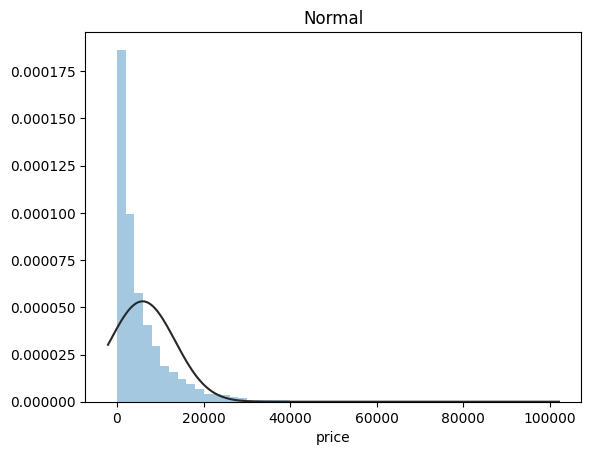

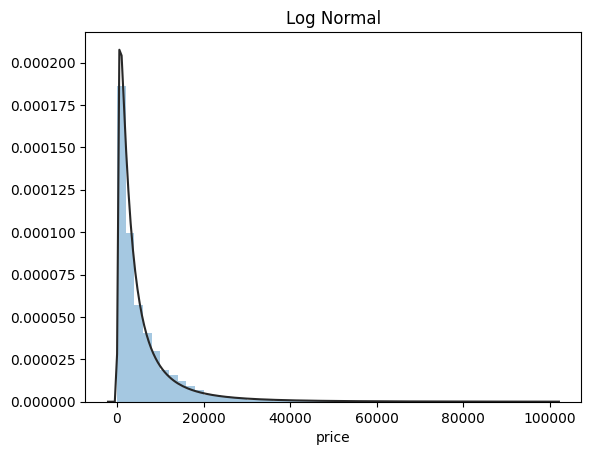

In [6]:
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
y = train['price']

plt.figure(1); plt.title('Normal')
sns.distplot(y, kde=False, fit=st.norm)
plt.figure(2); plt.title('Log Normal')
sns.distplot(y, kde=False, fit=st.lognorm)

#需要log

### 数据分布

In [5]:
for col in train.columns:
    print(f'--- Column: {col} ---')
    print(train[col].value_counts(dropna=False))
    print('\n')

# Saleid唯一，可以去掉，seller和offertype类别严重倾斜，可以去掉
# regDate有异常值（如20000008 ），power有异常值

--- Column: SaleID ---
SaleID
149999    1
0         1
1         1
2         1
3         1
         ..
19        1
20        1
21        1
22        1
23        1
Name: count, Length: 150000, dtype: int64


--- Column: name ---
name
708       282
387       282
55        280
1541      263
203       233
         ... 
129256      1
194047      1
68585       1
74847       1
171728      1
Name: count, Length: 99662, dtype: int64


--- Column: regDate ---
regDate
20000008    180
20000011    158
20000004    157
20000010    157
20000002    155
           ... 
20140009      1
20140002      1
19910807      1
19910801      1
19911211      1
Name: count, Length: 3894, dtype: int64


--- Column: model ---
model
0.0      11762
19.0      9573
4.0       8445
1.0       6038
29.0      5186
         ...  
209.0        2
242.0        2
240.0        2
NaN          1
247.0        1
Name: count, Length: 249, dtype: int64


--- Column: brand ---
brand
0     31480
4     16737
14    16089
10    14249
1     13794

In [2]:
# # 数字特征
numeric_features = ['power', 'kilometer', 'v_0', 'v_1', 'v_2', 'v_3', 'v_4', 
'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10', 'v_11', 'v_12', 'v_13','v_14' ]
#power有566种，可以当类别特征，kilometer有11种，也可以当类别特征

# # 类型特征
categorical_features = ['name', 'model', 'brand', 'bodyType', 'fuelType', 
'gearbox', 'notRepairedDamage', 'regionCode',]

In [13]:
# 类型特征分布
for cat_fea in categorical_features:
    print(cat_fea + "的特征分布如下：")
    print("{}特征有个{}不同的值".format(cat_fea, train[cat_fea].nunique()))
    print(train[cat_fea].value_counts())
    
#notRepairedDamage -是缺失值

name的特征分布如下：
name特征有个99662不同的值
name
708       282
387       282
55        280
1541      263
203       233
         ... 
129256      1
194047      1
68585       1
74847       1
171728      1
Name: count, Length: 99662, dtype: int64
model的特征分布如下：
model特征有个248不同的值
model
0.0      11762
19.0      9573
4.0       8445
1.0       6038
29.0      5186
         ...  
245.0        2
242.0        2
209.0        2
240.0        2
247.0        1
Name: count, Length: 248, dtype: int64
brand的特征分布如下：
brand特征有个40不同的值
brand
0     31480
4     16737
14    16089
10    14249
1     13794
6     10217
9      7306
5      4665
13     3817
11     2945
3      2461
7      2361
16     2223
8      2077
25     2064
27     2053
21     1547
15     1458
19     1388
20     1236
12     1109
22     1085
26      966
30      940
17      913
24      772
28      649
32      592
29      406
37      333
2       321
31      318
18      316
36      228
34      227
33      218
23      186
35      180
38       65
39        9
Name: count,

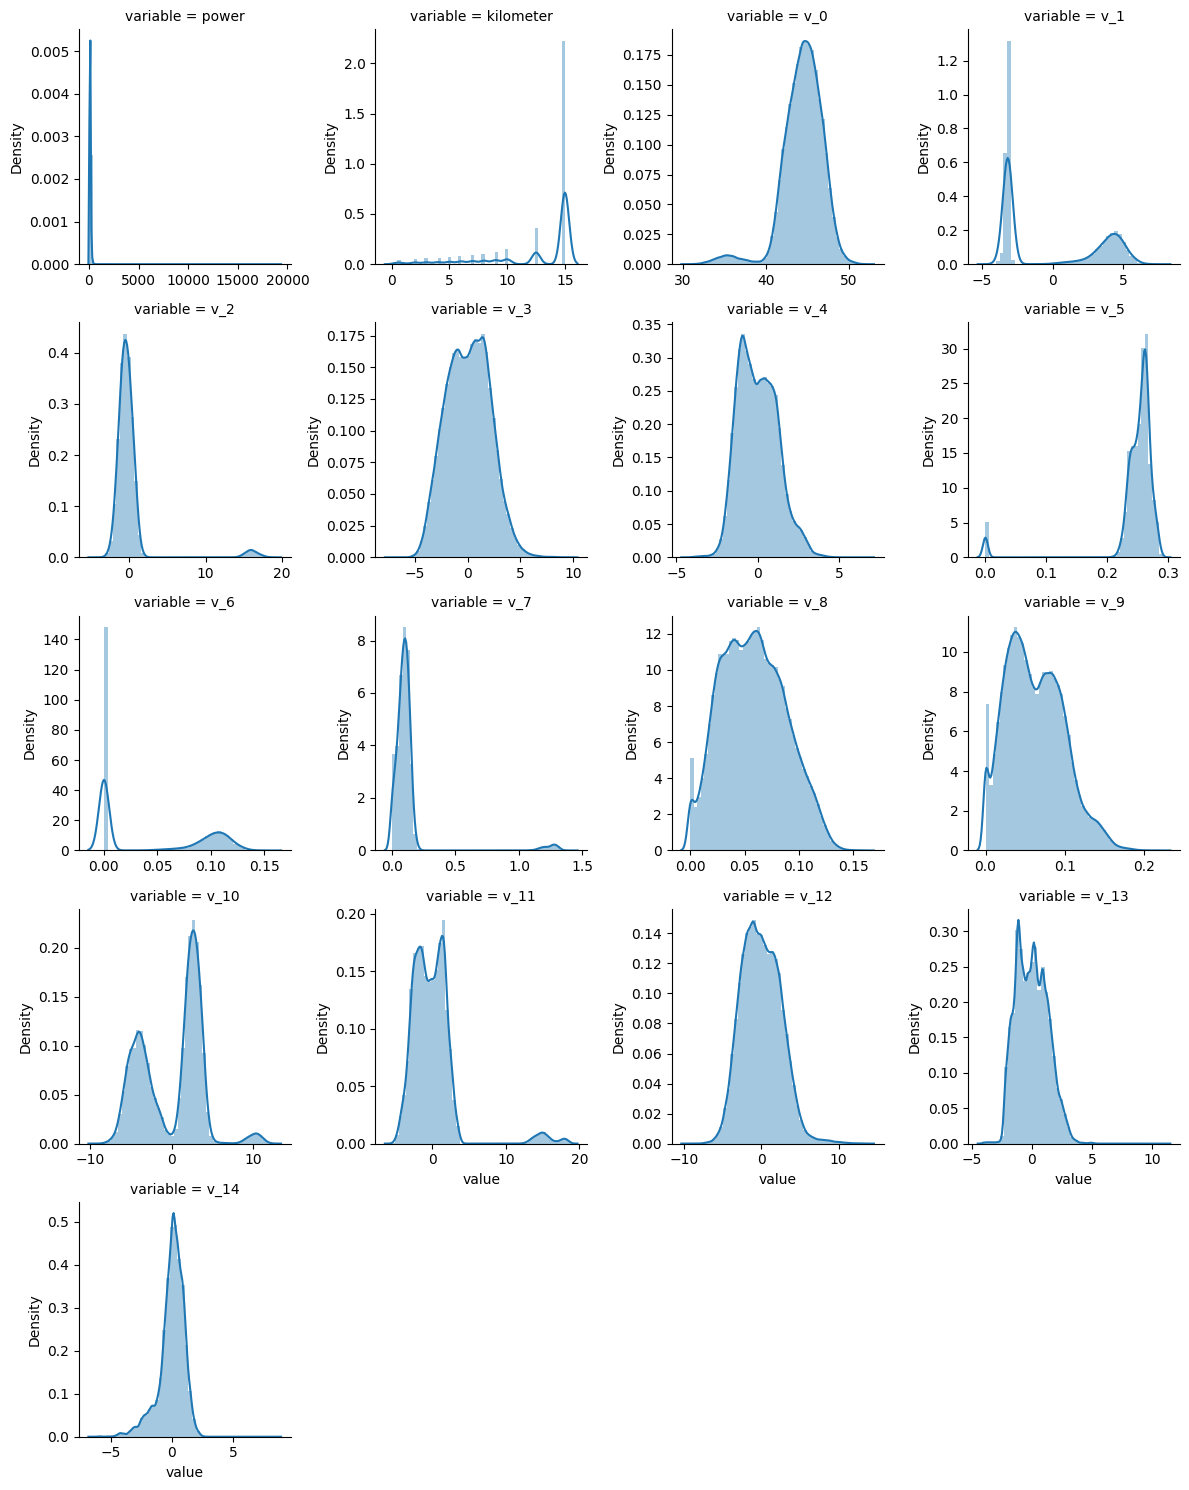

In [15]:
## 数字特征分布可视化
df = pd.melt(train, value_vars=numeric_features)
plot_grid = sns.FacetGrid(df, col="variable",  col_wrap=4, sharex=False, sharey=False)
plot_grid = plot_grid.map(sns.distplot, "value")

#power,v_2,v_5,v_7,应该有异常值

In [4]:
from scipy import stats
for feature in numeric_features:
    stat, p = stats.kstest(train[feature].dropna(), 'norm')
    print(f"{feature:>10}: KS p-value = {p:.4f}", end=" | ")
    if p > 0.05:
        print("Normal (适合3σ)")
    else:
        print("Non-Normal (适合IQR)")
#都不是正态分布，不能使用3σ剔除异常值

     power: KS p-value = 0.0000 | Non-Normal (适合IQR)
 kilometer: KS p-value = 0.0000 | Non-Normal (适合IQR)
       v_0: KS p-value = 0.0000 | Non-Normal (适合IQR)
       v_1: KS p-value = 0.0000 | Non-Normal (适合IQR)
       v_2: KS p-value = 0.0000 | Non-Normal (适合IQR)
       v_3: KS p-value = 0.0000 | Non-Normal (适合IQR)
       v_4: KS p-value = 0.0000 | Non-Normal (适合IQR)
       v_5: KS p-value = 0.0000 | Non-Normal (适合IQR)
       v_6: KS p-value = 0.0000 | Non-Normal (适合IQR)
       v_7: KS p-value = 0.0000 | Non-Normal (适合IQR)
       v_8: KS p-value = 0.0000 | Non-Normal (适合IQR)
       v_9: KS p-value = 0.0000 | Non-Normal (适合IQR)
      v_10: KS p-value = 0.0000 | Non-Normal (适合IQR)
      v_11: KS p-value = 0.0000 | Non-Normal (适合IQR)
      v_12: KS p-value = 0.0000 | Non-Normal (适合IQR)
      v_13: KS p-value = 0.0000 | Non-Normal (适合IQR)
      v_14: KS p-value = 0.0000 | Non-Normal (适合IQR)


### 相关性分析

In [16]:
# 数字特征相关性分析
numeric_features.append('price')
price_numeric = train[numeric_features]
correlation = price_numeric.corr()
print(correlation['price'].sort_values(ascending = False),'\n')

price        1.000000
v_12         0.692823
v_8          0.685798
v_0          0.628397
power        0.219834
v_5          0.164317
v_2          0.085322
v_6          0.068970
v_1          0.060914
v_14         0.035911
v_13        -0.013993
v_7         -0.053024
v_4         -0.147085
v_9         -0.206205
v_10        -0.246175
v_11        -0.275320
kilometer   -0.440519
v_3         -0.730946
Name: price, dtype: float64 



<AxesSubplot:title={'center':'Correlation of Numeric Features with Price'}>

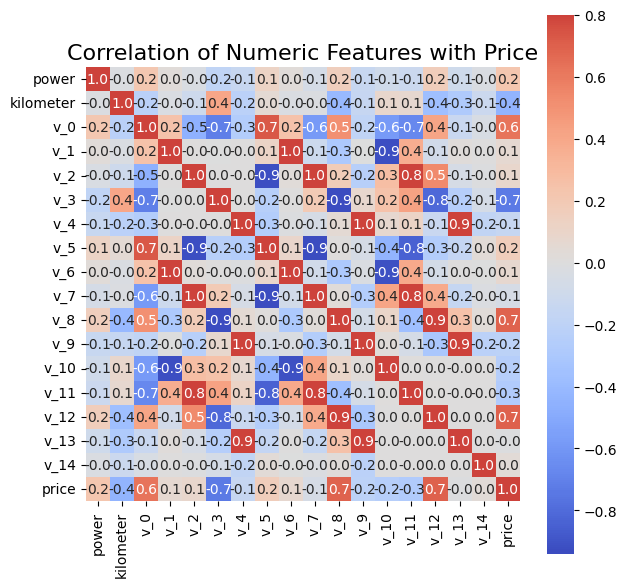

In [45]:
fig , ax = plt.subplots(figsize = (7, 7))

plt.title('Correlation of Numeric Features with Price',y=1,size=16)

sns.heatmap(correlation,square = True,  vmax=0.8,cmap='coolwarm',annot=True,fmt=".1f",center=0)

#16   27   49  强相关

In [19]:
for col in categorical_features:
    unique_count = train[col].nunique()
    print(f"Feature: {col} (Unique categories: {unique_count})")
    
    # 每个类别的样本数量
    counts = train[col].value_counts()
    
    # 每个类别对应的平均price
    mean_price = train.groupby(col)['price'].mean()
    
    # 合并成一个DataFrame方便查看
    stats_df = pd.DataFrame({
        'count': counts,
        'mean_price': mean_price
    }).sort_values(by='mean_price', ascending=False)
    
    print(stats_df, "\n")



Feature: name (Unique categories: 99662)
        count  mean_price
name                     
196214      1     99999.0
12083       1     99999.0
84186       1     99999.0
170113      1     99999.0
67960       1     99990.0
...       ...         ...
2776        1        12.0
178492      1        12.0
143472      1        12.0
34746       1        11.0
74714       1        11.0

[99662 rows x 2 columns] 

Feature: model (Unique categories: 248)
       count    mean_price
model                     
167.0    318  50765.056604
226.0     26  35547.961538
202.0     28  32766.285714
218.0     57  30377.526316
145.0    150  30110.073333
...      ...           ...
209.0      2    799.000000
164.0    279    774.068100
243.0      4    749.750000
242.0      2    749.500000
133.0     35    680.400000

[248 rows x 2 columns] 

Feature: brand (Unique categories: 40)
       count    mean_price
brand                     
24       772  36202.211140
37       333  16300.129129
2        321  12037.822430
26

In [22]:
#方差分析每个类别对price是否有影响，
#F值越大，说明不同类别之间的均值差异越显著，组间差异明显超过组内差异，说明类别对目标变量影响较大。
#p值小说明该类别对 price 有显著影响
import numpy as np
import scipy.stats as stats

min_samples = 10  # 最小样本数阈值

for col in categorical_features:
    # 按类别分组筛选样本数足够的组
    groups = []
    for val in train[col].unique():
        group_data = train.loc[train[col] == val, 'price']
        if len(group_data) >= min_samples:
            groups.append(group_data)
    if len(groups) < 2:
        print(f"ANOVA test for {col}: Not enough groups with >= {min_samples} samples.")
        continue
    
    try:
        f_val, p_val = stats.f_oneway(*groups)
        print(f"ANOVA test for {col}: F={f_val:.2f}, p={p_val:.8f}")
    except Exception as e:
        print(f"ANOVA test for {col}: Error - {e}")



ANOVA test for name: F=71.73, p=0.00000000
ANOVA test for model: F=319.20, p=0.00000000
ANOVA test for brand: F=925.44, p=0.00000000
ANOVA test for bodyType: F=2831.49, p=0.00000000
ANOVA test for fuelType: F=1489.80, p=0.00000000
ANOVA test for gearbox: F=17489.66, p=0.00000000
ANOVA test for notRepairedDamage: F=4626.50, p=0.00000000
ANOVA test for regionCode: F=2.35, p=0.00000000
